# Deber Outliers
![Logo](itq.jpg)
#### Nombre: Santiago Carrasco  
#### Fecha: 10/7/2026
https://github.com/Santi2w/pythonintroduccion2/blob/main/examenPracticoSantiagoCarrasco.ipynb

## Paso 2: Importación de librerías

En esta celda se importan las librerías necesarias para manejar archivos, trabajar con datos, realizar cálculos y crear gráficos. También se configuran Pandas y Seaborn para que la información se visualice de una manera más ordenada.

In [1]:
# Importamos herramientas para trabajar con archivos y carpetas
import os
import math
import zipfile

# Importamos librerías para manejar y analizar los datos
import numpy as np
import pandas as pd

# Importamos librerías para realizar gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos display para mostrar tablas de forma ordenada
from IPython.display import display

# Permitimos que Pandas muestre todas las columnas
pd.set_option("display.max_columns", None)

# Limitamos la visualización a un máximo de 100 filas
pd.set_option("display.max_rows", 100)

# Aplicamos un estilo con cuadrícula a los gráficos
sns.set_theme(style="whitegrid")

## Paso 3.1: Extracción del archivo ZIP

Esta celda indica la ubicación exacta del archivo comprimido, crea una carpeta para guardar su contenido y extrae el dataset. Además, comprueba que el archivo ZIP exista antes de intentar abrirlo.

In [2]:
# Ruta exacta donde está guardado el archivo ZIP
ruta_zip = r"C:\Users\ACER GAMER\Desktop\ipynb\zip dataset\archive (2).zip"

# Carpeta donde se extraerá el contenido del archivo ZIP
carpeta_dataset = r"C:\Users\ACER GAMER\Desktop\ipynb\zip dataset\dataset_medical"

# Verificamos si el archivo ZIP existe en la ruta indicada
if os.path.exists(ruta_zip):
    print("Archivo ZIP encontrado correctamente.")

    # Creamos la carpeta de extracción si todavía no existe
    os.makedirs(carpeta_dataset, exist_ok=True)

    # Abrimos el ZIP y extraemos todos sus archivos
    with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:
        archivo_zip.extractall(carpeta_dataset)

    # Mostramos mensajes de confirmación
    print("Dataset extraído correctamente.")
    print("Carpeta de extracción:", carpeta_dataset)

else:
    # Este mensaje aparece cuando la ruta del archivo es incorrecta
    print("No se encontró el archivo ZIP.")
    print("Revisa la siguiente ruta:")
    print(ruta_zip)

Archivo ZIP encontrado correctamente.
Dataset extraído correctamente.
Carpeta de extracción: C:\Users\ACER GAMER\Desktop\ipynb\zip dataset\dataset_medical


## Paso 3.2: Búsqueda y carga del archivo CSV

Aquí se busca automáticamente el archivo CSV dentro de la carpeta extraída. Cuando el archivo es encontrado, se carga en un DataFrame llamado `df` para comenzar el análisis.

In [3]:
# Creamos una lista vacía para guardar las rutas de los archivos CSV
archivos_csv = []

# Recorremos todas las carpetas y archivos extraídos
for carpeta, subcarpetas, archivos in os.walk(carpeta_dataset):
    for archivo in archivos:

        # Comprobamos si el archivo termina con la extensión .csv
        if archivo.lower().endswith(".csv"):

            # Guardamos la ruta completa del archivo encontrado
            archivos_csv.append(os.path.join(carpeta, archivo))

# Mostramos los archivos CSV encontrados
print("Archivos CSV encontrados:")
print(archivos_csv)

# Verificamos que se haya encontrado al menos un archivo CSV
if len(archivos_csv) > 0:

    # Seleccionamos el primer archivo CSV encontrado
    ruta_csv = archivos_csv[0]

    # Cargamos el archivo en un DataFrame de Pandas
    df = pd.read_csv(ruta_csv)

    # Mostramos información para confirmar la carga
    print("Dataset cargado correctamente.")
    print("Ruta del CSV:", ruta_csv)
    print("Dimensiones:", df.shape)

else:
    # Mensaje que aparece si el ZIP no contiene archivos CSV
    print("No se encontró ningún archivo CSV dentro del ZIP.")

Archivos CSV encontrados:
['C:\\Users\\ACER GAMER\\Desktop\\ipynb\\zip dataset\\dataset_medical\\medical_insurance.csv']
Dataset cargado correctamente.
Ruta del CSV: C:\Users\ACER GAMER\Desktop\ipynb\zip dataset\dataset_medical\medical_insurance.csv
Dimensiones: (100000, 54)


## Paso 4.1: Visualización de los primeros registros

Se utiliza `head()` para mostrar las primeras cinco filas del dataset. Esto permite observar rápidamente las columnas y algunos ejemplos de los datos.

In [4]:
# Mostramos las primeras cinco filas del dataset
print("Primeros cinco registros:")
display(df.head())

Primeros cinco registros:


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


## Paso 4.2: Visualización de los últimos registros

Se utiliza `tail()` para mostrar las últimas cinco filas del dataset y comprobar cómo termina la información almacenada.

In [5]:
# Mostramos las últimas cinco filas del dataset
print("Últimos cinco registros:")
display(df.tail())

Últimos cinco registros:


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,0,28.2,Never,Occasional,0,0,0,1,115.0,74.0,102.5,4.98,PPO,Bronze,500,10,10,0,3.93,0.3516,1295.04,329.32,27.44,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,0,27.6,Never,Occasional,0,0,0,1,101.0,66.0,177.1,5.66,PPO,Silver,5000,20,4,0,3.94,0.2637,1451.73,424.21,35.35,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,0,29.8,Former,Weekly,7,0,0,1,128.0,83.0,118.8,5.52,PPO,Gold,500,30,9,0,4.14,0.4505,2291.00,534.90,44.58,8,312.56,2500.48,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,2,21.9,Never,Occasional,4,0,0,2,110.0,73.0,134.9,5.25,POS,Bronze,2000,20,3,0,2.76,0.5604,1279.76,342.86,28.57,2,552.38,1104.76,1,0,0,0,0,0,0,0,0,0,1,0,0,2,2,1,0,0
99999,15796,44,Female,South,Rural,43700.0,Some College,Married,Employed,2,0,29.2,Never,NaN,1,0,0,0,115.0,72.0,59.5,5.78,PPO,Silver,1000,20,10,0,2.78,0.2857,465.70,265.88,22.16,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0


## Paso 4.3: Dimensiones del dataset

La propiedad `shape` muestra la cantidad total de filas y columnas del conjunto de datos.

In [6]:
# Mostramos la cantidad de filas y columnas del dataset
print("Cantidad de filas y columnas:")
print(df.shape)

Cantidad de filas y columnas:
(100000, 54)


## Paso 4.4: Información general del dataset

El método `info()` presenta los nombres de las columnas, los tipos de datos, la cantidad de valores no nulos y el uso de memoria.

In [7]:
# Mostramos información general sobre las columnas y sus tipos de datos
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       10000

## Paso 4.5: Resumen estadístico

El método `describe()` calcula estadísticas descriptivas de las variables, como la media, desviación estándar, valores mínimos, máximos y cuartiles.

In [8]:
# Generamos un resumen estadístico de todas las columnas
print("Resumen estadístico:")

# La transposición permite observar las variables en filas
display(df.describe(include="all").T)

Resumen estadístico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,47.5215,15.988752,0.0,37.0,48.0,58.0,100.0
sex,100000,3,Female,49193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,100000,5,South,28029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
urban_rural,100000,3,Urban,60019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,100000.0,NaN,NaN,NaN,49873.905,46800.214127,1100.0,21100.0,36200.0,62200.0,1061800.0
education,100000,6,Bachelors,27996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,100000,4,Married,53252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,55269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_size,100000.0,NaN,NaN,NaN,2.4309,1.075126,1.0,2.0,2.0,3.0,9.0


## Paso 5.1: Identificación de valores nulos

En esta celda se crea una tabla de calidad que presenta el tipo de dato, la cantidad y porcentaje de valores nulos, y el número de valores únicos de cada columna.

In [9]:
# Creamos una tabla con información sobre la calidad de cada columna
resumen_calidad = pd.DataFrame({
    # Tipo de dato de la variable
    "Tipo de dato": df.dtypes.astype(str),

    # Cantidad total de valores nulos
    "Valores nulos": df.isnull().sum(),

    # Porcentaje de valores nulos
    "Porcentaje nulos": (df.isnull().sum() / len(df) * 100).round(2),

    # Cantidad de valores diferentes
    "Valores únicos": df.nunique()
})

# Mostramos la tabla de calidad
display(resumen_calidad)

,Tipo de dato,Valores nulos,Porcentaje nulos,Valores únicos
person_id,int64,0,0.00,100000
age,int64,0,0.00,101
sex,object,0,0.00,3
region,object,0,0.00,5
urban_rural,object,0,0.00,3
income,float64,0,0.00,2987
education,object,0,0.00,6
marital_status,object,0,0.00,4
employment_status,object,0,0.00,4
household_size,int64,0,0.00,9


## Paso 5.2: Identificación de registros duplicados

Se cuentan las filas repetidas del dataset mediante el método `duplicated()`.

In [10]:
# Contamos cuántas filas están repetidas
duplicados = df.duplicated().sum()

# Mostramos el resultado
print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 0


## Paso 5.3: Revisión de los tipos de datos

Esta celda muestra de forma separada el tipo de dato asignado a cada variable.

In [11]:
# Mostramos el tipo de dato correspondiente a cada columna
print("Tipos de datos:")

# Convertimos la información en una tabla para verla mejor
display(df.dtypes.to_frame(name="Tipo de dato"))

Tipos de datos:


,Tipo de dato
person_id,int64
age,int64
sex,object
region,object
urban_rural,object
income,float64
education,object
marital_status,object
employment_status,object
household_size,int64


## Paso 6: Selección de variables numéricas

Se seleccionan únicamente las columnas numéricas. La variable `person_id` se excluye porque es un identificador y no representa una característica médica para el análisis.

In [12]:
# Seleccionamos todas las columnas que tienen datos numéricos
variables_numericas = df.select_dtypes(include=np.number).columns.tolist()

# Excluimos person_id porque solamente identifica a cada persona
variables_numericas_analisis = [
    columna
    for columna in variables_numericas
    if columna != "person_id"
]

# Mostramos la cantidad y los nombres de las variables seleccionadas
print("Cantidad de variables numéricas:", len(variables_numericas_analisis))
print(variables_numericas_analisis)

Cantidad de variables numéricas: 43
['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


## Paso 7.1: Función para generar Boxplots

Se crea una función que permite construir varios diagramas de caja de forma organizada. Los Boxplots ayudan a observar la distribución de los datos y detectar posibles valores atípicos.

In [13]:
# Creamos una función para generar varios diagramas de caja
def mostrar_boxplots(
    datos,
    columnas,
    titulo,
    graficos_por_figura=12,
    columnas_por_fila=3
):
    # Dividimos las variables en grupos para no amontonar los gráficos
    for inicio in range(0, len(columnas), graficos_por_figura):

        # Seleccionamos el grupo de columnas que se dibujará
        grupo = columnas[inicio:inicio + graficos_por_figura]

        # Calculamos la cantidad de filas necesarias
        cantidad_filas = math.ceil(len(grupo) / columnas_por_fila)

        # Creamos el espacio donde aparecerán los gráficos
        fig, ejes = plt.subplots(
            cantidad_filas,
            columnas_por_fila,
            figsize=(18, cantidad_filas * 4)
        )

        # Convertimos los ejes en una lista para recorrerlos fácilmente
        ejes = np.array(ejes).reshape(-1)

        # Dibujamos un Boxplot por cada variable
        for eje, columna in zip(ejes, grupo):
            sns.boxplot(x=datos[columna].dropna(), ax=eje)

            # Colocamos el nombre de la variable como título
            eje.set_title(columna)
            eje.set_xlabel("")

        # Ocultamos los espacios que no fueron utilizados
        for eje in ejes[len(grupo):]:
            eje.axis("off")

        # Colocamos el título general de la figura
        fig.suptitle(
            f"{titulo} - variables {inicio + 1} a {inicio + len(grupo)}",
            fontsize=16
        )

        # Ajustamos los espacios y mostramos la figura
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

## Paso 7.2: Boxplots del dataset original

Se ejecuta la función anterior utilizando las variables numéricas del dataset original para visualizar los posibles Outliers antes de la limpieza.

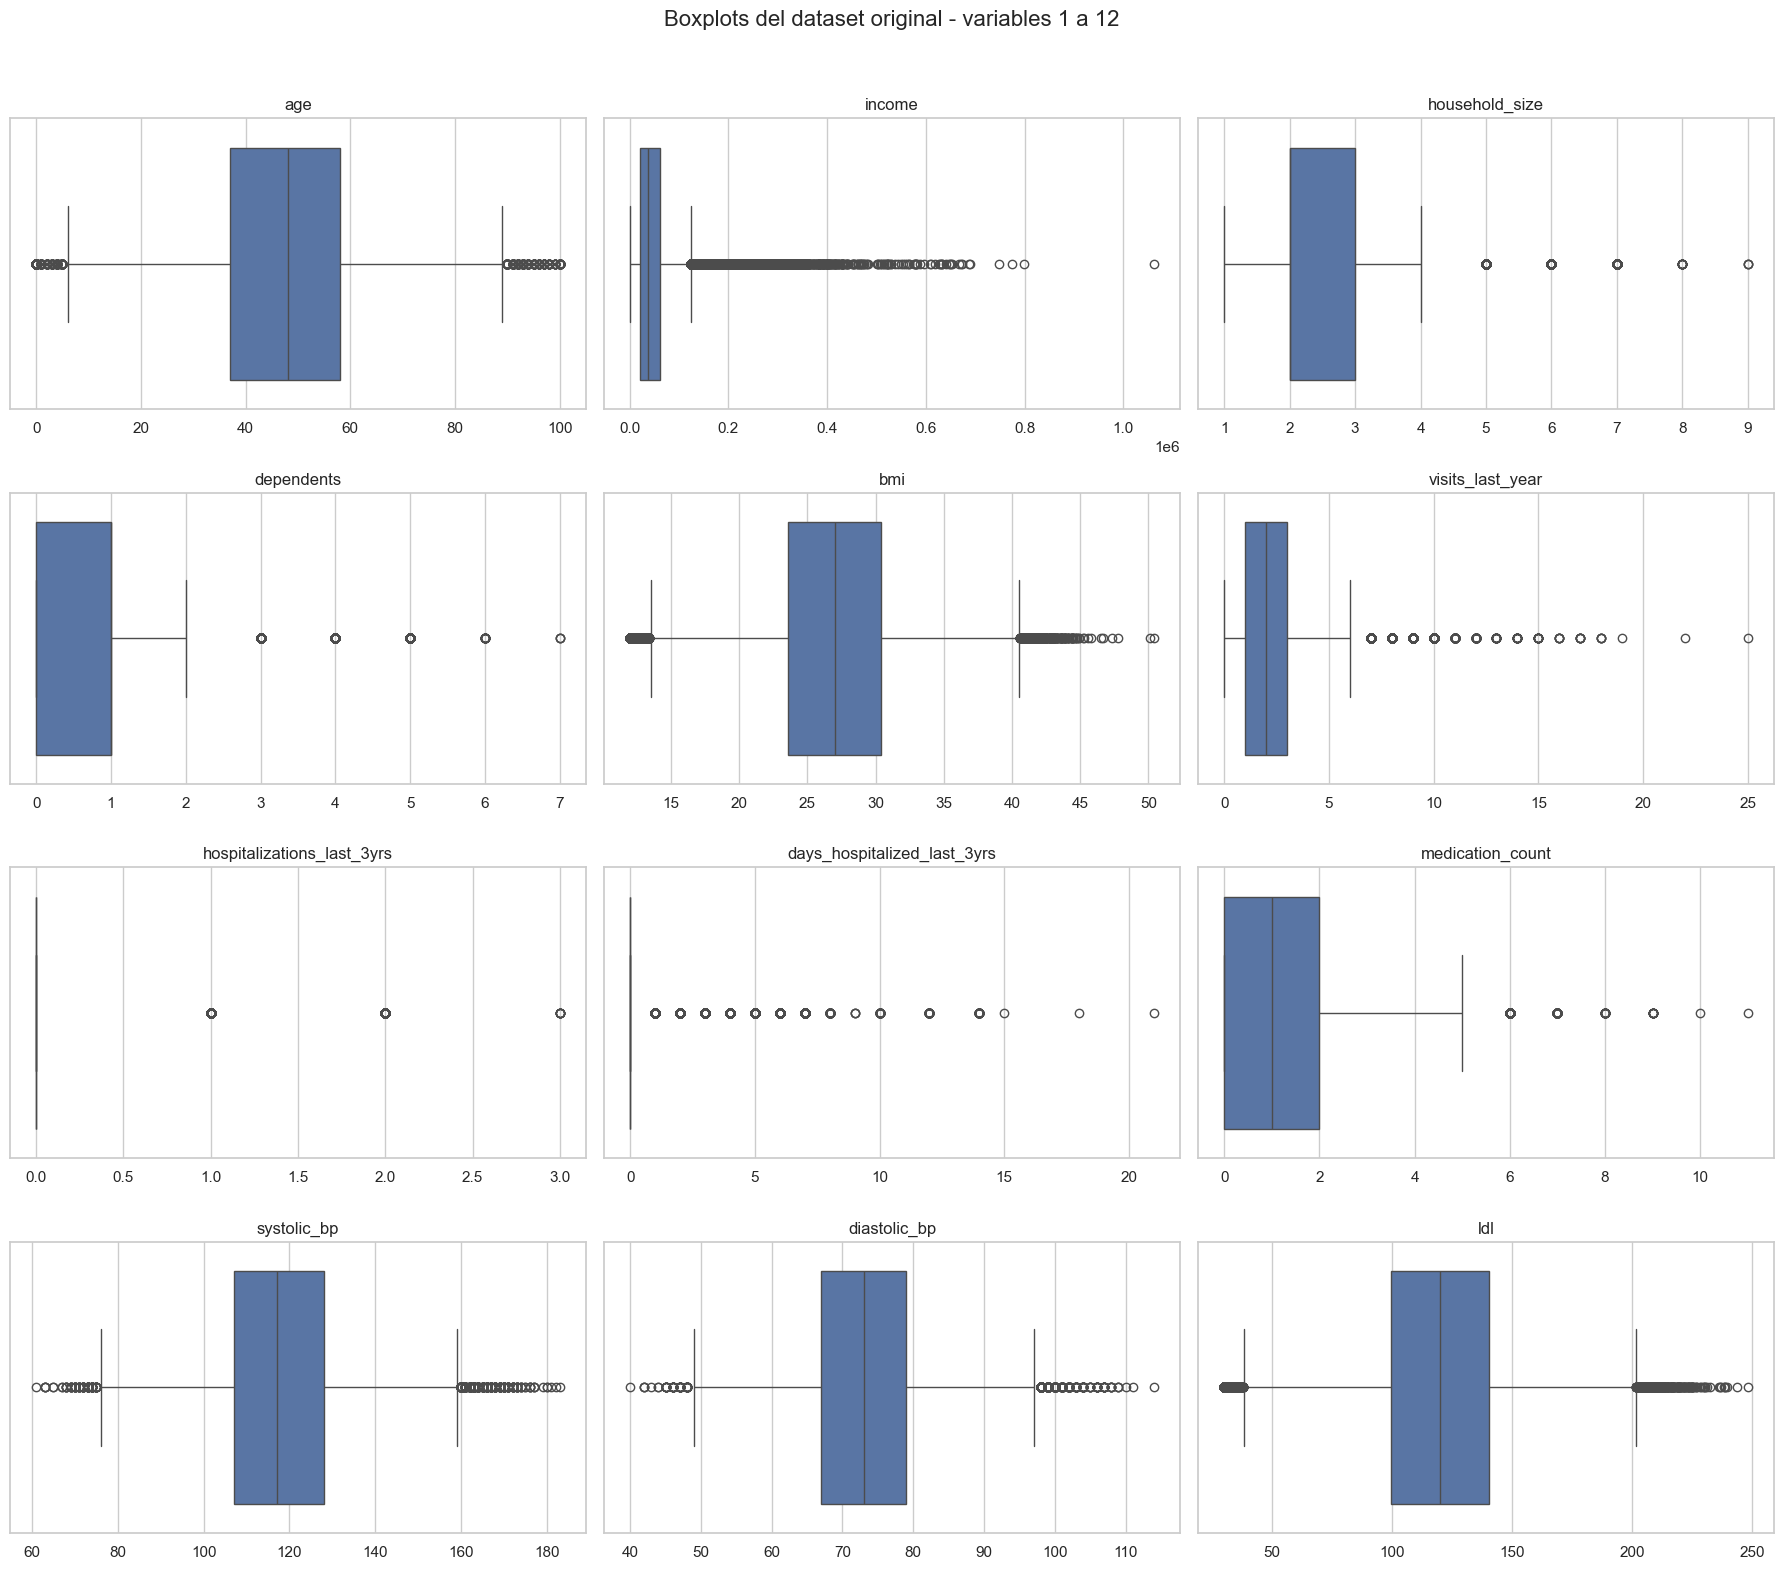

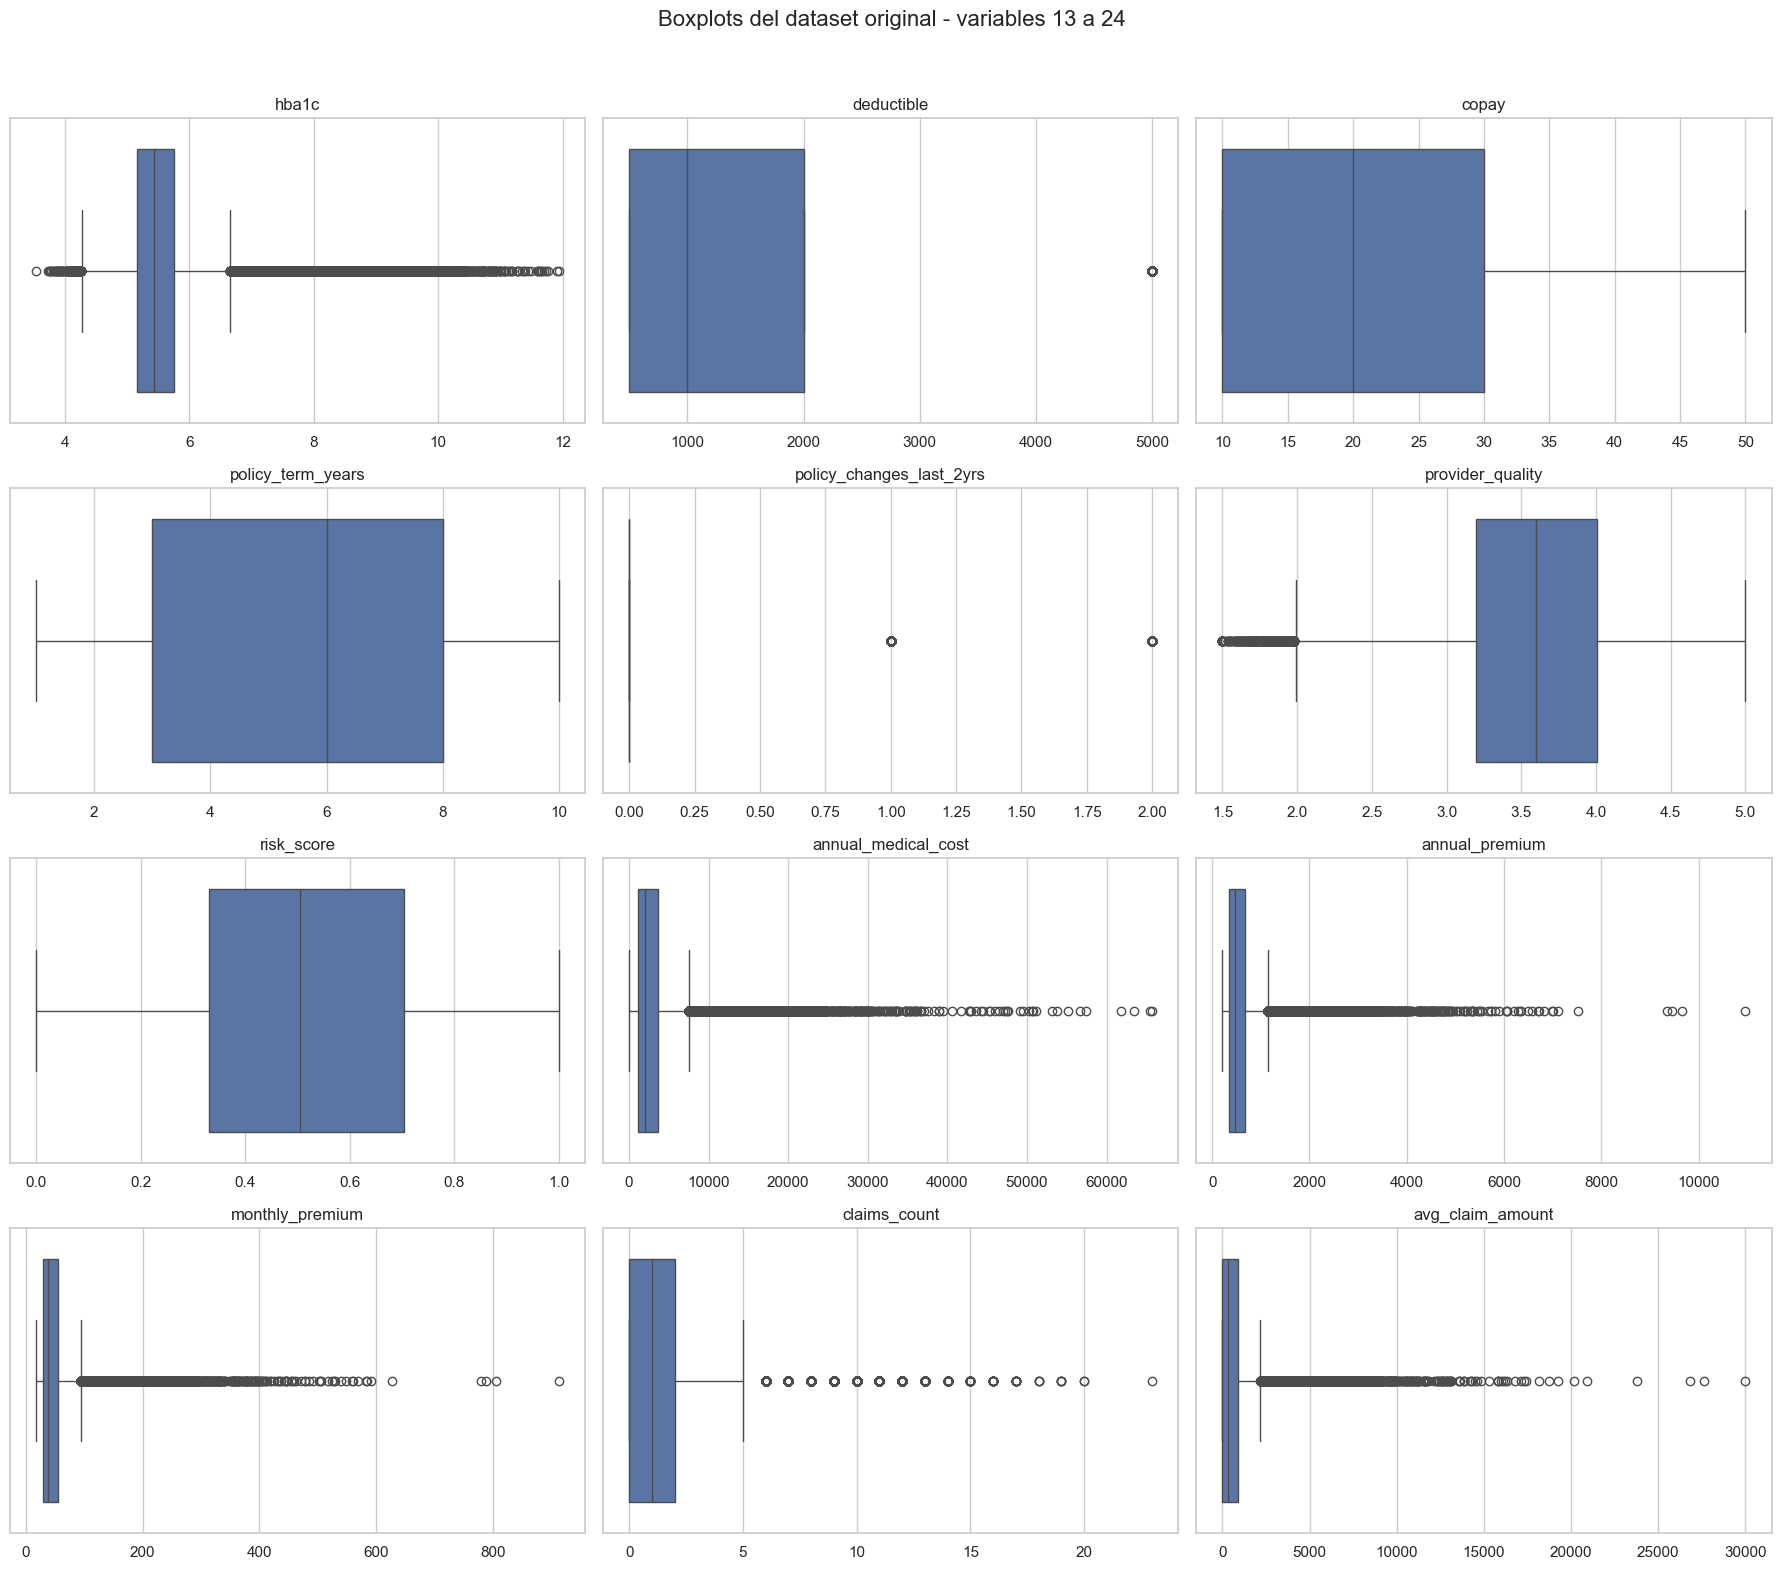

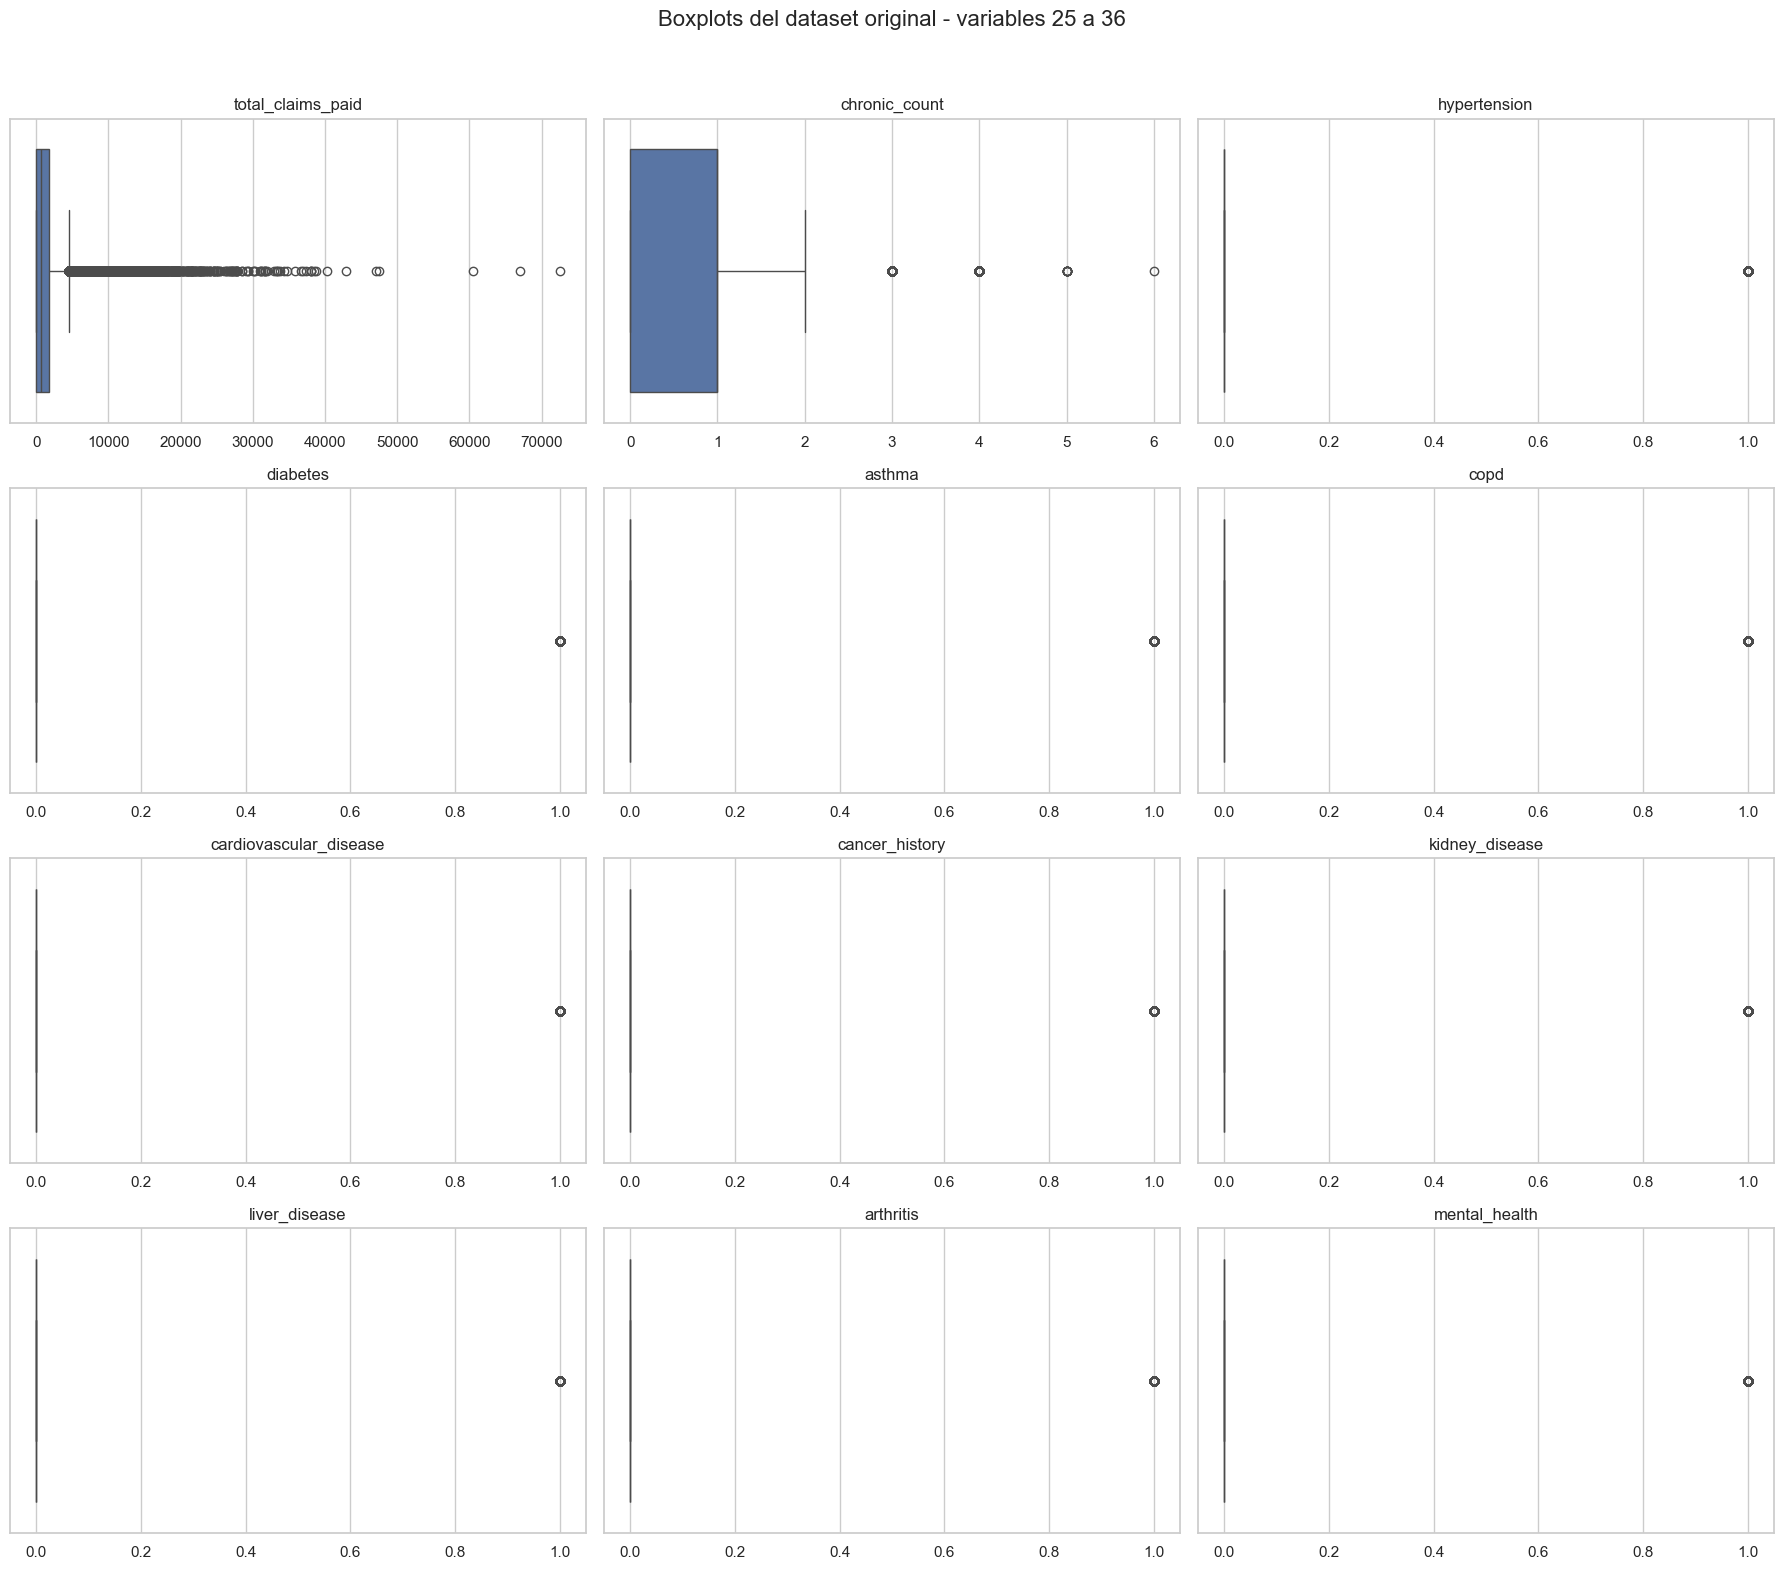

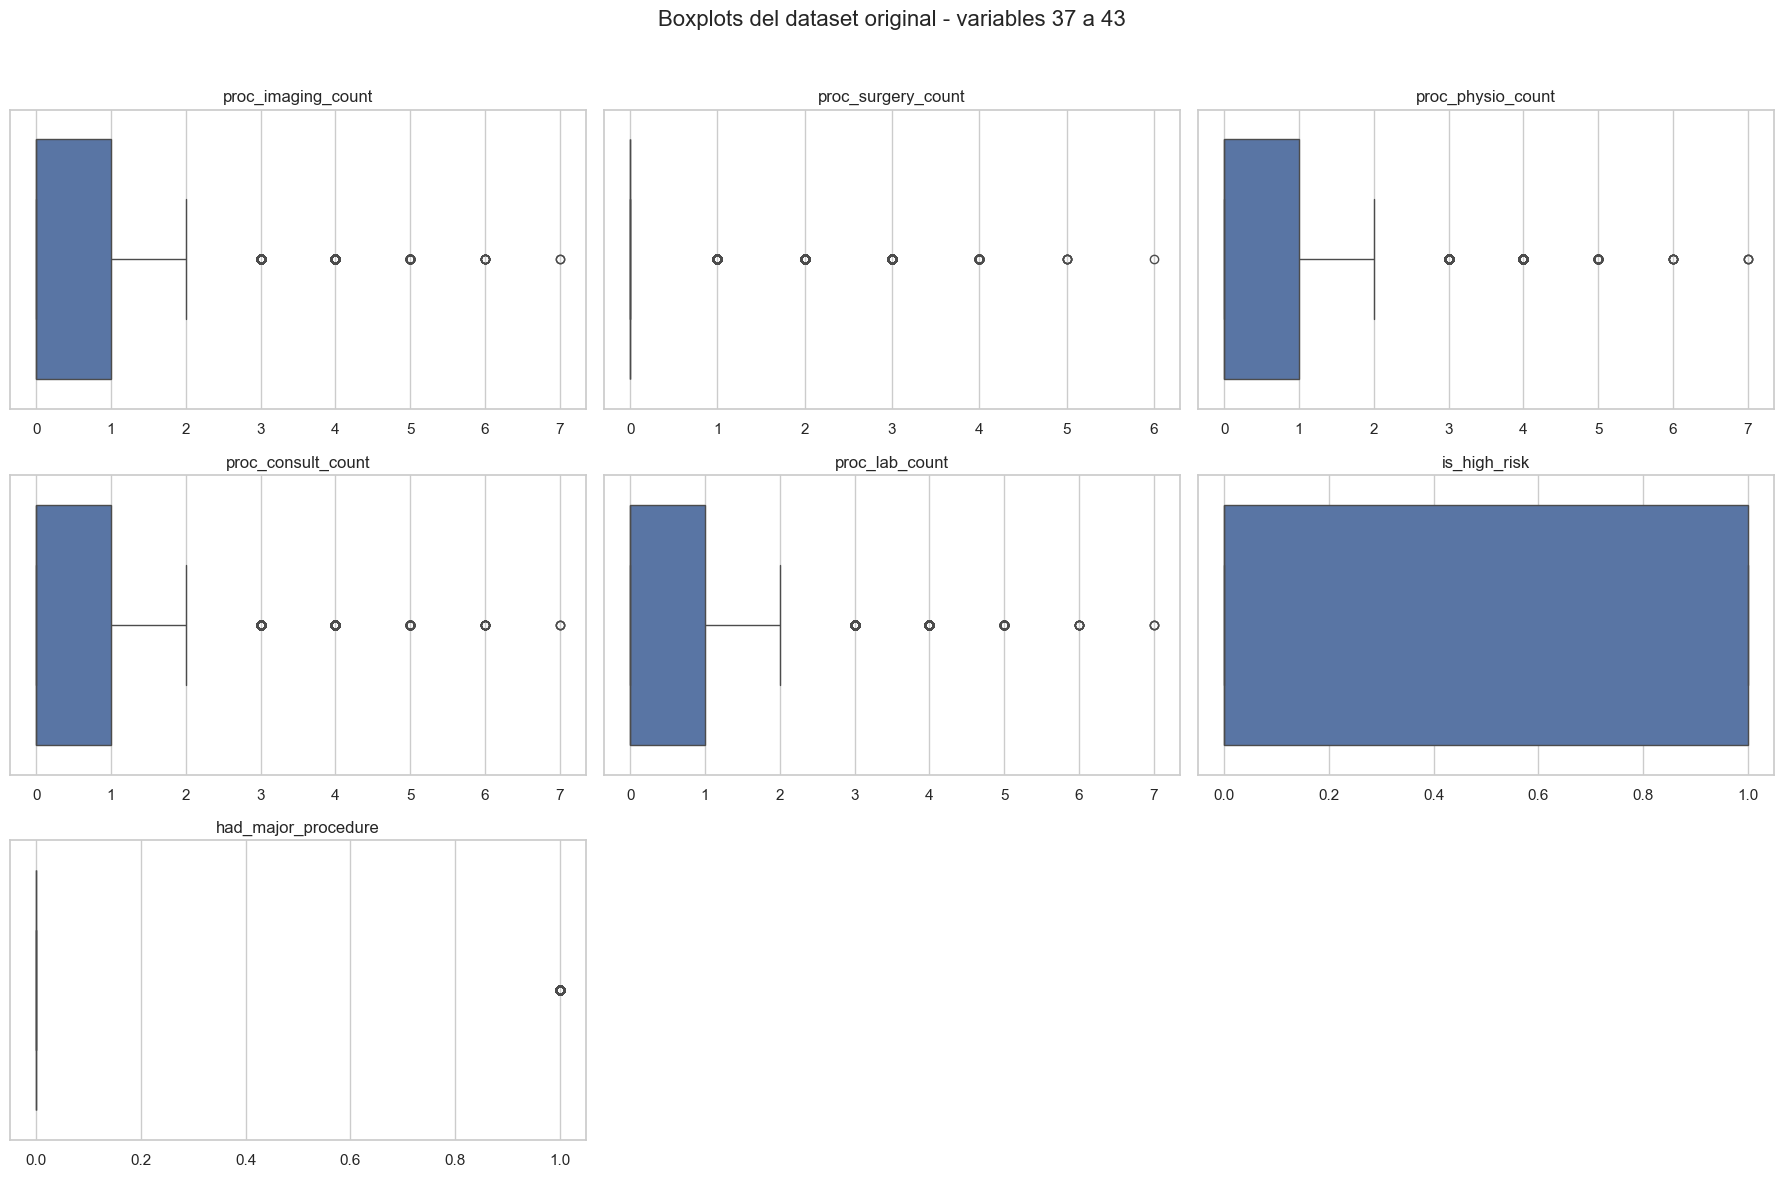

In [15]:
# Generamos los Boxplots de todas las variables numéricas
mostrar_boxplots(
    datos=df,
    columnas=variables_numericas_analisis,
    titulo="Boxplots del dataset original"
)

## Paso 9.1: Selección de variables para aplicar IQR

Se seleccionan las variables numéricas que tienen más de dos valores diferentes. De esta manera se excluyen variables binarias, porque el método IQR no es apropiado para columnas que solo contienen valores como 0 y 1.

In [16]:
# Seleccionamos variables numéricas con más de dos valores diferentes
variables_iqr = [
    columna
    for columna in variables_numericas_analisis
    if df[columna].nunique(dropna=True) > 2
]

# Mostramos las variables que serán analizadas con el método IQR
print("Variables que serán analizadas con IQR:")
print(variables_iqr)

Variables que serán analizadas con IQR:
['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count']


## Paso 9.2: Detección de Outliers con el método IQR

Para cada variable se calculan el primer cuartil, el tercer cuartil, el rango intercuartílico y los límites permitidos. Los valores que se encuentran fuera de esos límites son contados como Outliers.

In [17]:
# Creamos una lista para guardar los resultados del método IQR
resultados_iqr = []

# Recorremos cada variable numérica seleccionada
for columna in variables_iqr:

    # Eliminamos temporalmente los valores nulos para calcular los cuartiles
    serie = df[columna].dropna()

    # Calculamos el primer y el tercer cuartil
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    # Calculamos el rango intercuartílico
    iqr = q3 - q1

    # Calculamos los límites inferior y superior permitidos
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Identificamos los datos que están fuera de los límites
    condicion_outlier = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    )

    # Contamos los Outliers y calculamos su porcentaje
    cantidad_outliers = condicion_outlier.sum()
    porcentaje_outliers = cantidad_outliers / len(df) * 100

    # Guardamos los resultados de la variable analizada
    resultados_iqr.append({
        "Variable": columna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de outliers": cantidad_outliers,
        "Porcentaje de outliers": porcentaje_outliers
    })

# Convertimos los resultados en un DataFrame
tabla_iqr = pd.DataFrame(resultados_iqr)

# Ordenamos la tabla desde la variable con más Outliers
tabla_iqr = tabla_iqr.sort_values(
    by="Cantidad de outliers",
    ascending=False
).reset_index(drop=True)

# Mostramos la tabla con dos decimales
display(tabla_iqr.round(2))

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers
0,proc_surgery_count,0.00,0.00,0.00,0.00,0.00,12519,12.52
1,hospitalizations_last_3yrs,0.00,0.00,0.00,0.00,0.00,8969,8.97
2,days_hospitalized_last_3yrs,0.00,0.00,0.00,0.00,0.00,8969,8.97
3,hba1c,5.16,5.76,0.60,4.26,6.66,7465,7.46
4,total_claims_paid,0.00,1795.52,1795.52,-2693.28,4488.81,6963,6.96
5,annual_premium,352.07,666.70,314.63,-119.87,1138.64,6927,6.93
6,monthly_premium,29.34,55.56,26.22,-9.99,94.89,6925,6.93
7,annual_medical_cost,1175.12,3707.96,2532.84,-2624.14,7507.22,6772,6.77
8,avg_claim_amount,0.00,872.22,872.22,-1308.32,2180.54,6581,6.58
9,dependents,0.00,1.00,1.00,-1.50,2.50,6306,6.31


## Paso 10.1: Variables con mayor cantidad de Outliers

Se muestran las quince variables que presentan la mayor cantidad y porcentaje de valores atípicos.

In [19]:
# Indicamos qué información se mostrará
print("Variables con mayor cantidad de valores atípicos:")

# Mostramos las quince variables con mayor cantidad de Outliers
display(
    tabla_iqr[
        [
            "Variable",
            "Cantidad de outliers",
            "Porcentaje de outliers"
        ]
    ].head(15).round(2)
)

Variables con mayor cantidad de valores atípicos:


,Variable,Cantidad de outliers,Porcentaje de outliers
0,proc_surgery_count,12519,12.52
1,hospitalizations_last_3yrs,8969,8.97
2,days_hospitalized_last_3yrs,8969,8.97
3,hba1c,7465,7.46
4,total_claims_paid,6963,6.96
5,annual_premium,6927,6.93
6,monthly_premium,6925,6.93
7,annual_medical_cost,6772,6.77
8,avg_claim_amount,6581,6.58
9,dependents,6306,6.31


## Paso 10.2: Gráfico de cantidad de Outliers

Se crea un gráfico de barras para comparar visualmente la cantidad de Outliers encontrada en cada variable.

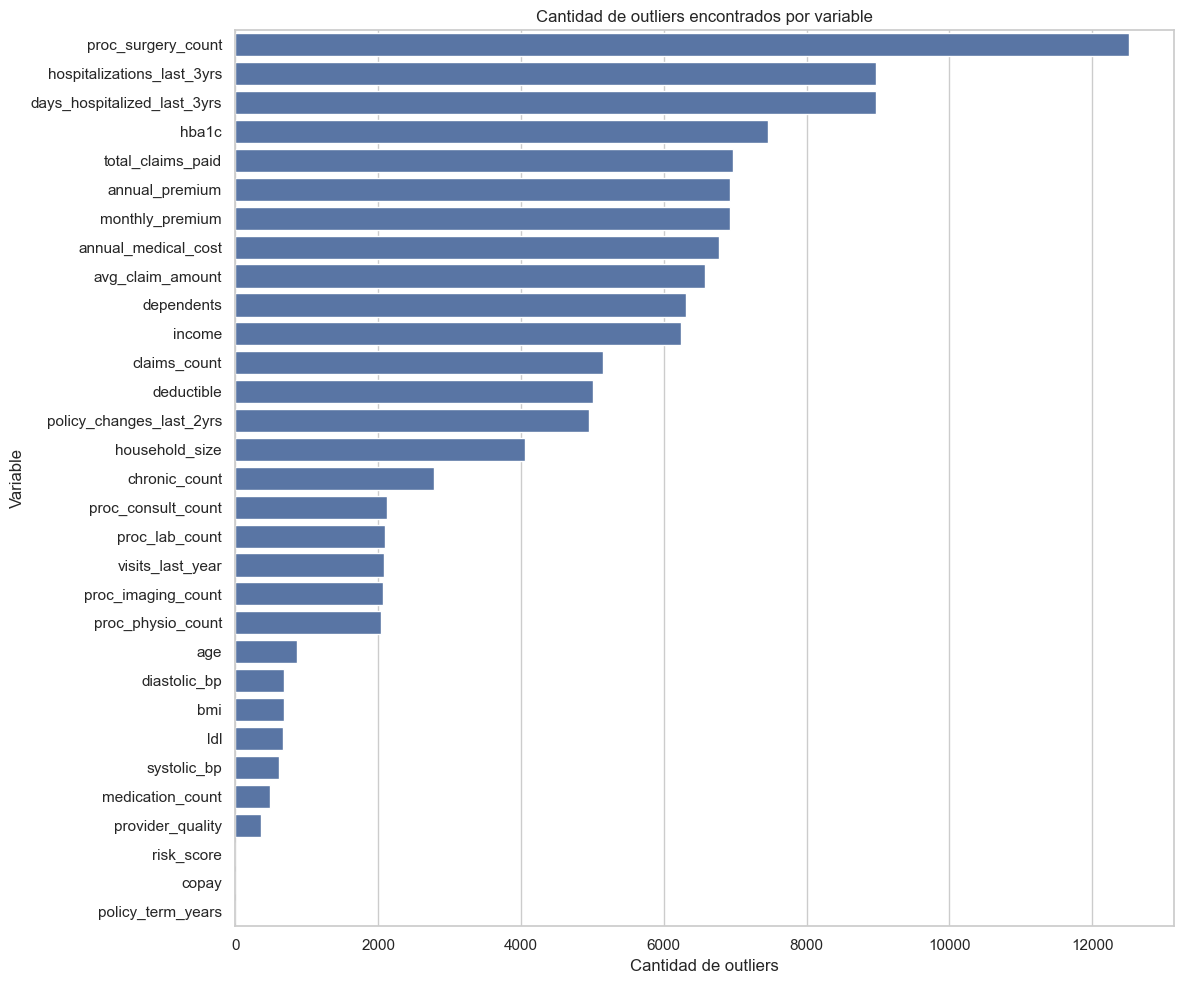

In [20]:
# Definimos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Creamos un gráfico de barras con la cantidad de Outliers
sns.barplot(
    data=tabla_iqr,
    x="Cantidad de outliers",
    y="Variable"
)

# Agregamos el título y los nombres de los ejes
plt.title("Cantidad de outliers encontrados por variable")
plt.xlabel("Cantidad de outliers")
plt.ylabel("Variable")

# Ajustamos los espacios y mostramos el gráfico
plt.tight_layout()
plt.show()

## Paso 11.1: Selección de columnas para la limpieza

Se eligen las variables cuyo rango intercuartílico es mayor que cero. Esto evita aplicar la limpieza sobre columnas que no presentan variación suficiente.

In [21]:
# Seleccionamos solamente las variables cuyo IQR es mayor que cero
columnas_limpieza = tabla_iqr.loc[
    tabla_iqr["IQR"] > 0,
    "Variable"
].tolist()

# Mostramos las variables que serán utilizadas para eliminar Outliers
print("Variables utilizadas para limpiar el dataset:")
print(columnas_limpieza)

Variables utilizadas para limpiar el dataset:
['hba1c', 'total_claims_paid', 'annual_premium', 'monthly_premium', 'annual_medical_cost', 'avg_claim_amount', 'dependents', 'income', 'claims_count', 'deductible', 'household_size', 'chronic_count', 'proc_consult_count', 'proc_lab_count', 'visits_last_year', 'proc_imaging_count', 'proc_physio_count', 'age', 'diastolic_bp', 'bmi', 'ldl', 'systolic_bp', 'medication_count', 'provider_quality', 'risk_score', 'copay', 'policy_term_years']


## Paso 11.2: Eliminación de registros con Outliers

Se construye un filtro que conserva únicamente los registros ubicados dentro de los límites IQR de todas las variables seleccionadas. El resultado se guarda en `df_sin_outliers`.

In [22]:
# Creamos un filtro inicial que acepta todos los registros
filtro_sin_outliers = pd.Series(
    True,
    index=df.index
)

# Recorremos cada variable seleccionada para la limpieza
for columna in columnas_limpieza:

    # Calculamos los cuartiles y el rango intercuartílico
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    # Calculamos los límites permitidos
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Verificamos qué datos se encuentran dentro de los límites
    dentro_de_limites = df[columna].between(
        limite_inferior,
        limite_superior
    )

    # Conservamos los valores nulos porque no son Outliers
    dentro_de_limites = dentro_de_limites | df[columna].isnull()

    # Combinamos el filtro actual con los filtros anteriores
    filtro_sin_outliers = filtro_sin_outliers & dentro_de_limites

# Creamos una copia del dataset con los registros que pasaron el filtro
df_sin_outliers = df.loc[filtro_sin_outliers].copy()

# Mostramos un mensaje al finalizar
print("Limpieza terminada.")

Limpieza terminada.


## Paso 12.1: Comparación de registros

Se crea una tabla que compara la cantidad de registros del dataset original con la cantidad de registros que permanecen después de eliminar los Outliers.

In [23]:
# Creamos una tabla para comparar la cantidad de registros
comparacion_registros = pd.DataFrame({
    "Dataset": [
        "Dataset original",
        "Dataset sin outliers"
    ],
    "Número de registros": [
        len(df),
        len(df_sin_outliers)
    ]
})

# Mostramos la comparación
display(comparacion_registros)

,Dataset,Número de registros
0,Dataset original,100000
1,Dataset sin outliers,59105


## Paso 12.2: Registros y porcentaje eliminados

Se calcula cuántos registros fueron eliminados y qué porcentaje representan respecto al dataset original.

In [24]:
# Calculamos la cantidad de registros eliminados
registros_eliminados = len(df) - len(df_sin_outliers)

# Calculamos el porcentaje de registros eliminados
porcentaje_eliminado = (
    registros_eliminados / len(df)
) * 100

# Mostramos los resultados de la limpieza
print("Registros originales:", len(df))
print("Registros después de la limpieza:", len(df_sin_outliers))
print("Registros eliminados:", registros_eliminados)
print("Porcentaje eliminado:", round(porcentaje_eliminado, 2), "%")

Registros originales: 100000
Registros después de la limpieza: 59105
Registros eliminados: 40895
Porcentaje eliminado: 40.89 %


## Paso 12.3: Comparación de medidas estadísticas

Se calculan la media, mediana y desviación estándar antes y después de la limpieza para observar cómo cambiaron las variables.

In [25]:
# Calculamos media, mediana y desviación estándar antes de la limpieza
estadisticas_antes = df[columnas_limpieza].agg(
    ["mean", "median", "std"]
).T

# Calculamos las mismas medidas después de la limpieza
estadisticas_despues = df_sin_outliers[columnas_limpieza].agg(
    ["mean", "median", "std"]
).T

# Cambiamos los nombres de las columnas del dataset original
estadisticas_antes.columns = [
    "Media antes",
    "Mediana antes",
    "Desviación estándar antes"
]

# Cambiamos los nombres de las columnas del dataset limpio
estadisticas_despues.columns = [
    "Media después",
    "Mediana después",
    "Desviación estándar después"
]

# Unimos ambas tablas para compararlas
comparacion_estadistica = pd.concat(
    [
        estadisticas_antes,
        estadisticas_despues
    ],
    axis=1
)

# Mostramos los resultados con dos decimales
display(comparacion_estadistica.round(2))

,Media antes,Mediana antes,Desviación estándar antes,Media después,Mediana después,Desviación estándar después
hba1c,5.61,5.44,0.85,5.41,5.41,0.40
total_claims_paid,1377.88,642.55,2305.46,730.59,380.90,939.54
annual_premium,582.32,463.58,399.58,464.87,420.41,174.20
monthly_premium,48.53,38.63,33.30,38.74,35.03,14.52
annual_medical_cost,3009.45,2082.57,3127.46,2083.19,1742.72,1381.68
avg_claim_amount,656.51,318.02,1072.66,403.85,215.14,507.35
dependents,0.90,1.00,0.95,0.74,1.00,0.74
income,49873.90,36200.00,46800.21,40888.44,33900.00,26788.22
claims_count,1.62,1.00,2.03,1.16,1.00,1.33
deductible,1226.72,1000.00,1019.62,1027.76,1000.00,551.74


## Paso 12.4: Cambios en los indicadores estadísticos

Esta celda calcula la diferencia entre las medidas estadísticas del dataset limpio y las del dataset original.

In [26]:
# Calculamos el cambio producido en la media
comparacion_estadistica["Cambio en la media"] = (
    comparacion_estadistica["Media después"] -
    comparacion_estadistica["Media antes"]
)

# Calculamos el cambio producido en la mediana
comparacion_estadistica["Cambio en la mediana"] = (
    comparacion_estadistica["Mediana después"] -
    comparacion_estadistica["Mediana antes"]
)

# Calculamos el cambio producido en la desviación estándar
comparacion_estadistica["Cambio en la desviación"] = (
    comparacion_estadistica["Desviación estándar después"] -
    comparacion_estadistica["Desviación estándar antes"]
)

# Mostramos la tabla completa con dos decimales
display(comparacion_estadistica.round(2))

,Media antes,Mediana antes,Desviación estándar antes,Media después,Mediana después,Desviación estándar después,Cambio en la media,Cambio en la mediana,Cambio en la desviación
hba1c,5.61,5.44,0.85,5.41,5.41,0.40,-0.20,-0.03,-0.44
total_claims_paid,1377.88,642.55,2305.46,730.59,380.90,939.54,-647.28,-261.65,-1365.93
annual_premium,582.32,463.58,399.58,464.87,420.41,174.20,-117.45,-43.17,-225.38
monthly_premium,48.53,38.63,33.30,38.74,35.03,14.52,-9.79,-3.60,-18.78
annual_medical_cost,3009.45,2082.57,3127.46,2083.19,1742.72,1381.68,-926.26,-339.85,-1745.78
avg_claim_amount,656.51,318.02,1072.66,403.85,215.14,507.35,-252.66,-102.88,-565.31
dependents,0.90,1.00,0.95,0.74,1.00,0.74,-0.16,0.00,-0.21
income,49873.90,36200.00,46800.21,40888.44,33900.00,26788.22,-8985.47,-2300.00,-20012.00
claims_count,1.62,1.00,2.03,1.16,1.00,1.33,-0.47,0.00,-0.70
deductible,1226.72,1000.00,1019.62,1027.76,1000.00,551.74,-198.97,0.00,-467.88


## Paso 13: Boxplots después de la limpieza

Se generan nuevamente los diagramas de caja para verificar visualmente el resultado obtenido después de eliminar los registros considerados Outliers.

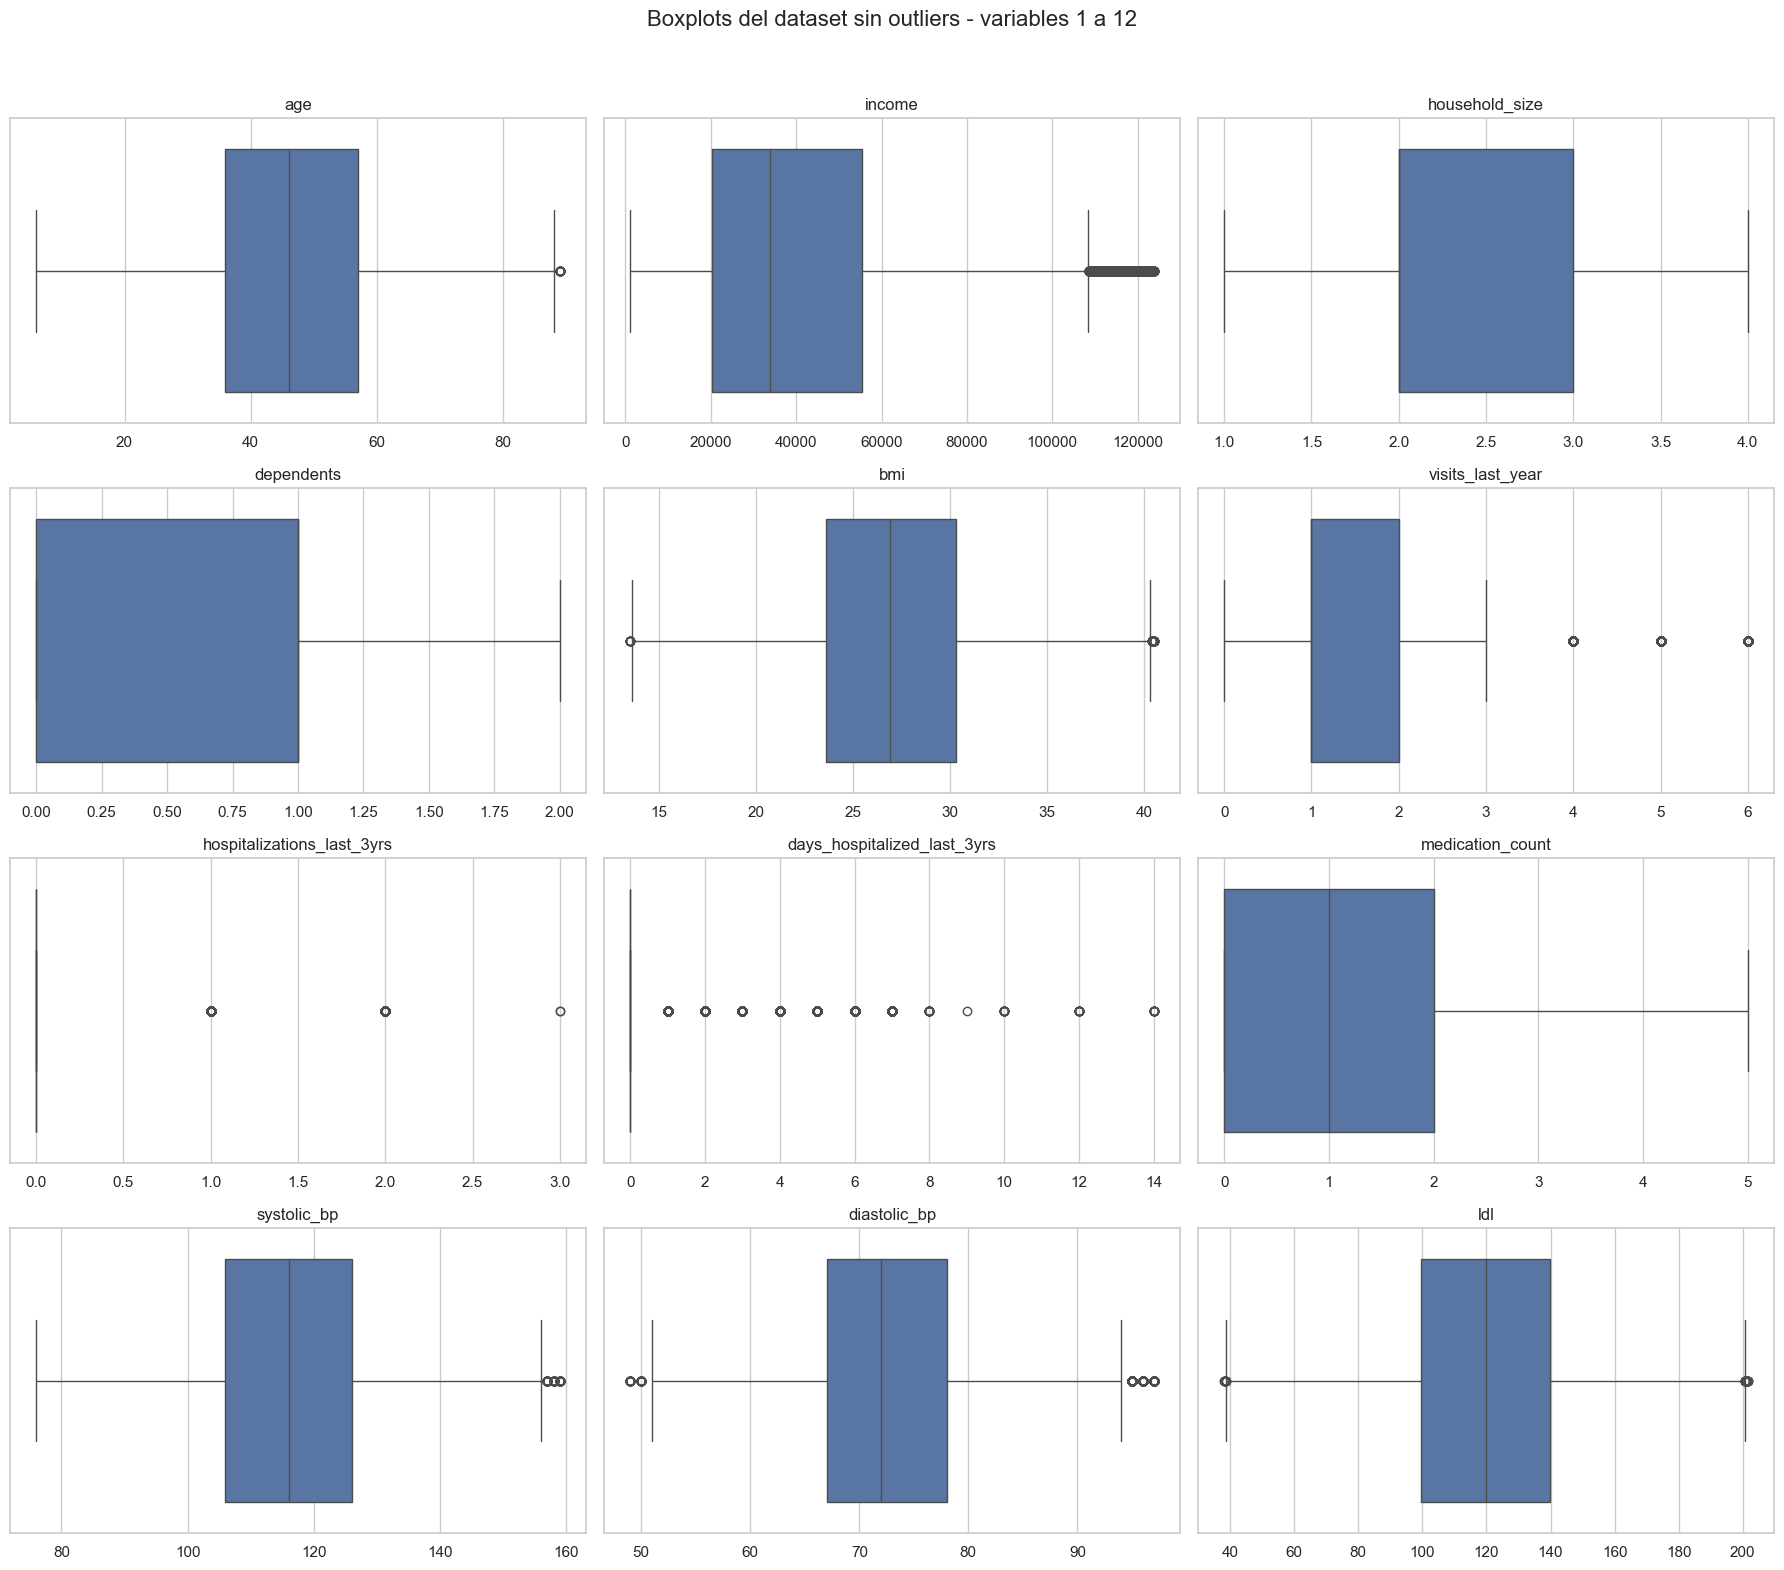

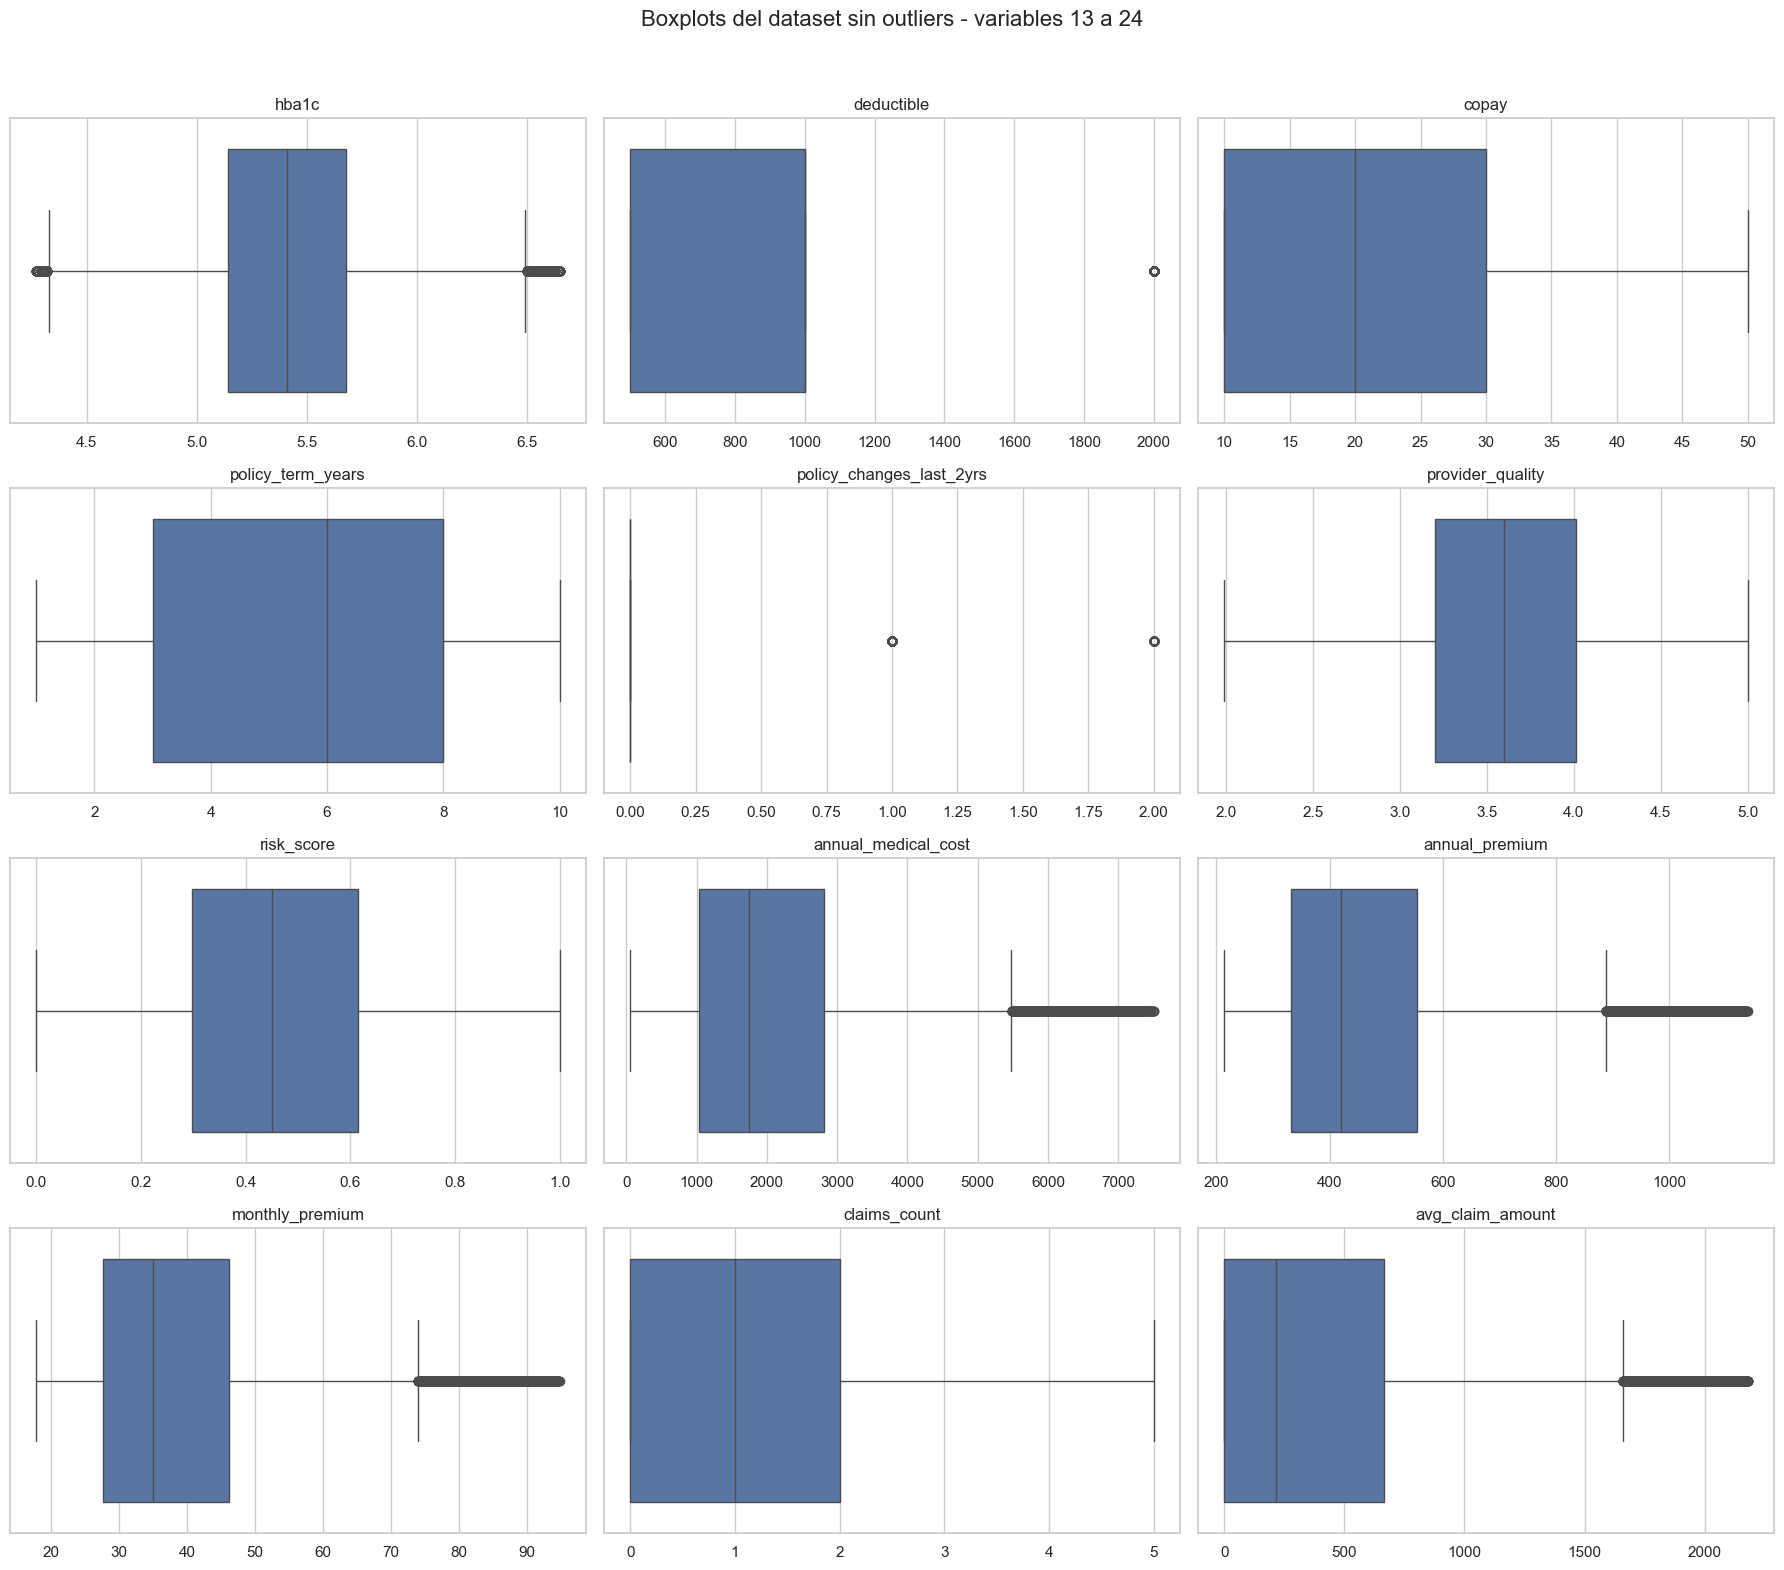

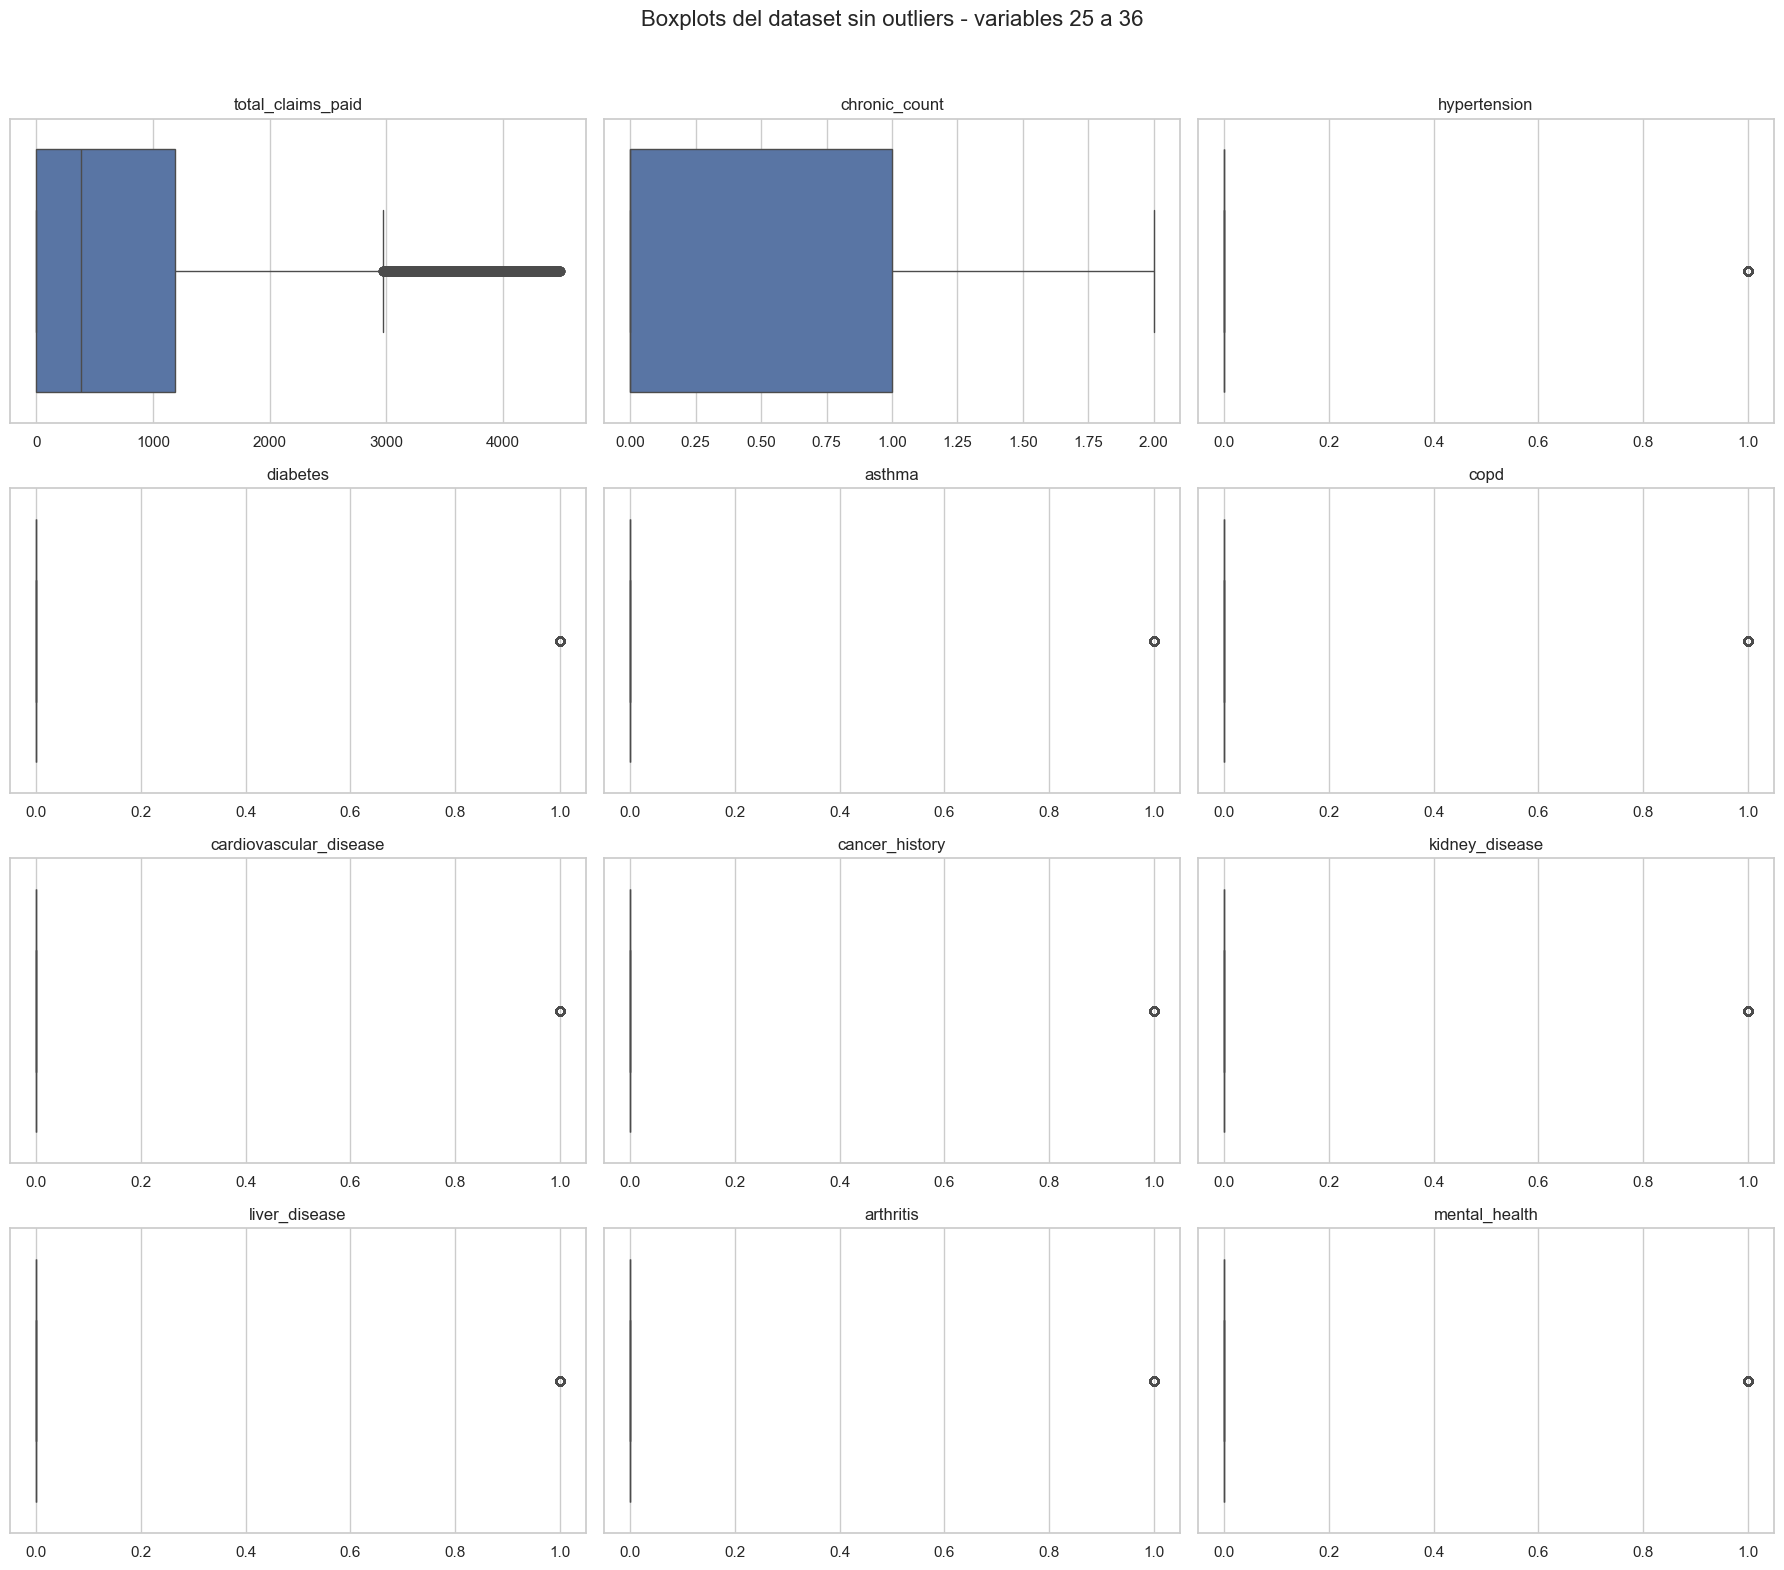

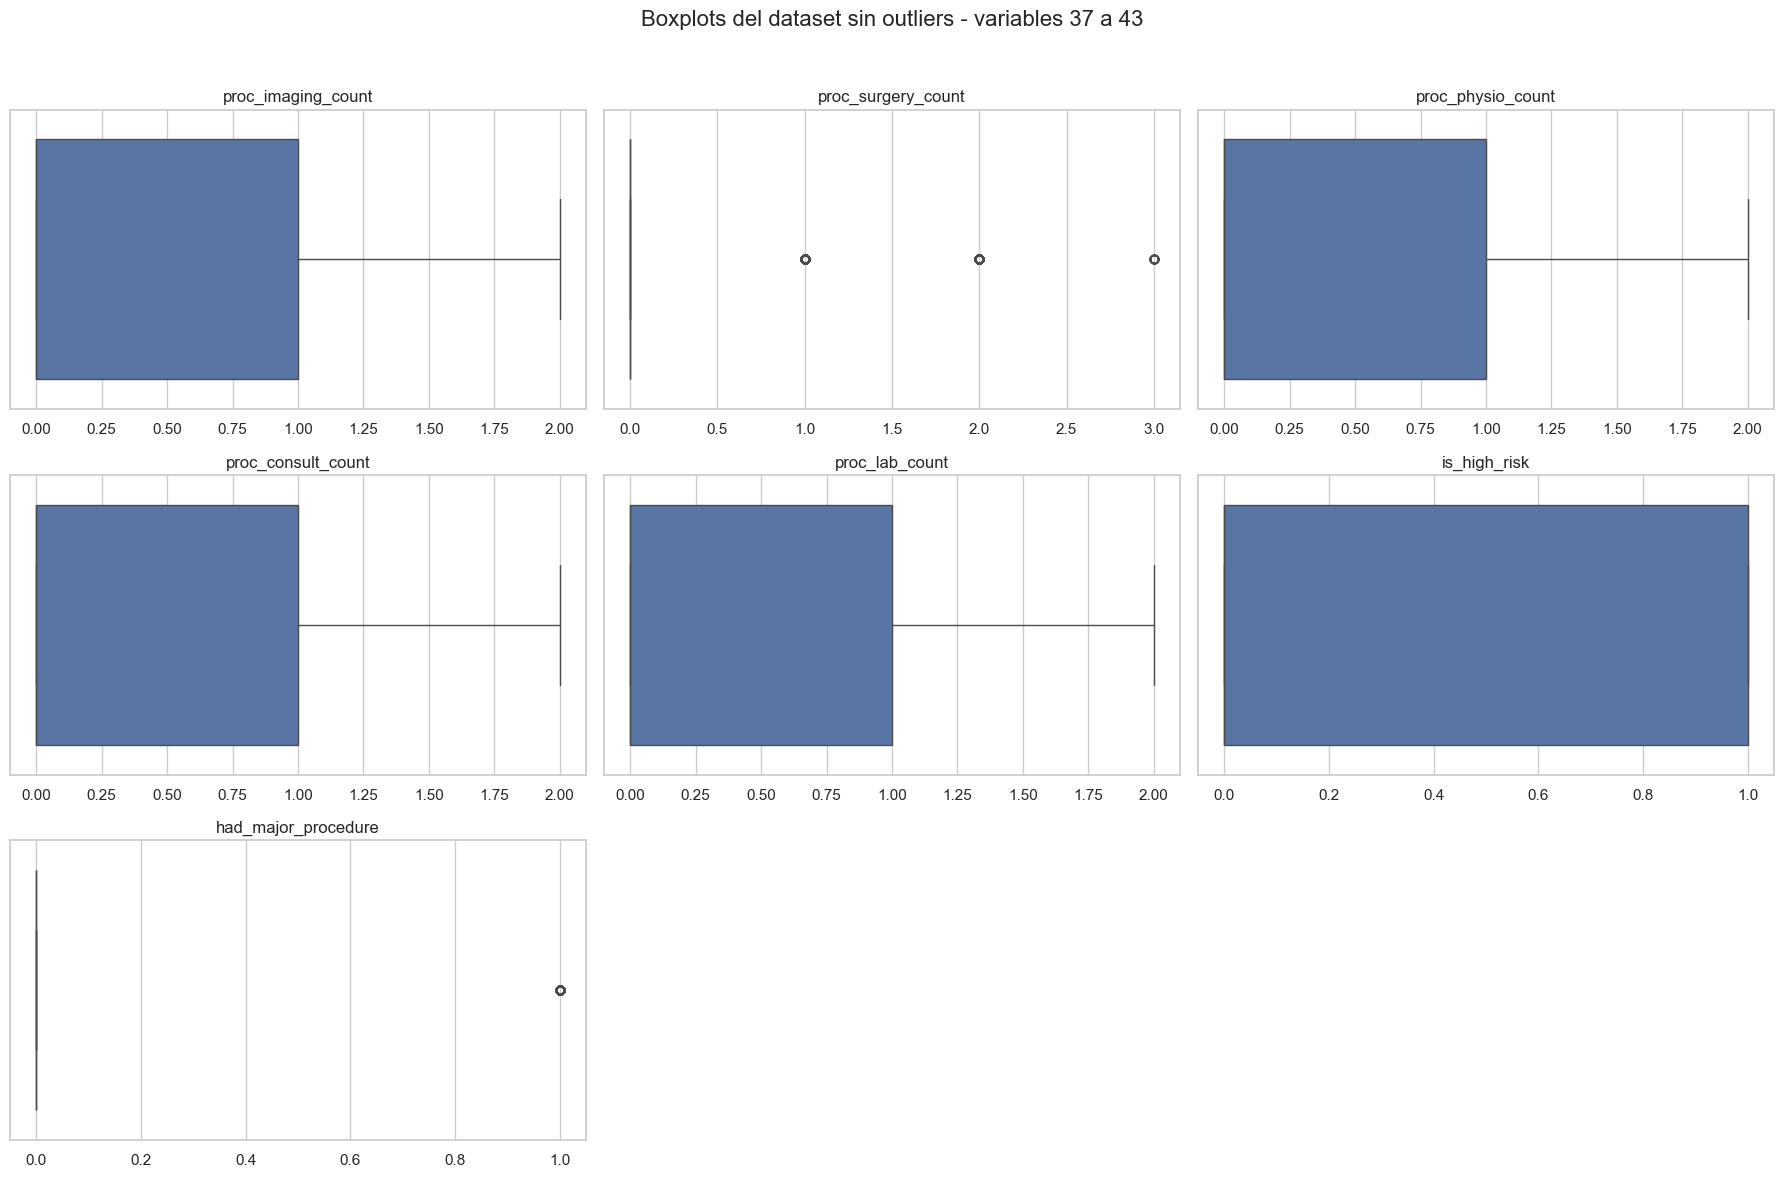

In [27]:
# Generamos nuevamente los Boxplots utilizando el dataset limpio
mostrar_boxplots(
    datos=df_sin_outliers,
    columnas=variables_numericas_analisis,
    titulo="Boxplots del dataset sin outliers"
)

## Paso 14.1: Guardado del dataset limpio

El nuevo conjunto de datos se guarda en un archivo CSV llamado medical_insurance_sin_outliers.csv.

In [28]:
# Definimos el nombre del archivo de salida
nombre_archivo_salida = "medical_insurance_sin_outliers.csv"

# Guardamos el DataFrame limpio sin incluir los índices de Pandas
df_sin_outliers.to_csv(
    nombre_archivo_salida,
    index=False
)

# Mostramos la información del archivo creado
print("Dataset guardado correctamente.")
print("Nombre del archivo:", nombre_archivo_salida)
print("Ubicación:", os.path.abspath(nombre_archivo_salida))

Dataset guardado correctamente.
Nombre del archivo: medical_insurance_sin_outliers.csv
Ubicación: C:\Users\ACER GAMER\Desktop\ipynb\medical_insurance_sin_outliers.csv


## Paso 14.2: Comprobación del archivo guardado

Finalmente, se vuelve a cargar el archivo limpio para comprobar sus dimensiones y visualizar sus primeros registros.

In [29]:
# Cargamos nuevamente el archivo limpio para comprobarlo
df_comprobacion = pd.read_csv(
    "medical_insurance_sin_outliers.csv"
)

# Mostramos sus dimensiones
print("Dimensiones del archivo guardado:")
print(df_comprobacion.shape)

# Mostramos los primeros registros del archivo
display(df_comprobacion.head())

Dimensiones del archivo guardado:
(59105, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
1,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0
2,84005,36,Male,West,Rural,38900.0,Masters,Single,Employed,1,0,21.6,Never,Occasional,0,0,0,0,114.0,76.0,153.9,5.54,HMO,Silver,500,10,3,0,4.30,0.1978,1746.68,414.60,34.55,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0
3,60768,53,Male,North,Suburban,60700.0,No HS,Divorced,Retired,1,0,27.8,Current,NaN,0,0,0,0,138.0,84.0,151.5,5.52,HMO,Gold,1000,10,4,0,4.38,0.8571,5684.12,1028.51,85.71,0,0.00,0.00,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0
4,50075,28,Male,South,Urban,23600.0,Bachelors,Married,Employed,4,2,31.0,Never,Weekly,0,0,0,0,99.0,62.0,108.6,4.49,EPO,Gold,500,10,4,0,3.24,0.1978,4150.00,802.60,66.88,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0
